In [ ]:
#step 1 import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving loan_data.csv to loan_data (1).csv


In [ ]:
#step 2 load data set
df=pd.read_csv("loan_data.csv")
df.head(7)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
5,LP001024,Male,Yes,2,Graduate,No,3200,700.0,70.0,360.0,1.0,Urban,Y
6,LP001027,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y


In [ ]:
df["Loan_Status"].value_counts()

,count
Loan_Status,
Y,271
N,110


In [ ]:



df.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y


In [ ]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
376,LP002953,Male,Yes,3+,Graduate,No,5703,0.0,128.0,360.0,1.0,Urban,Y
377,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
378,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
379,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
380,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [ ]:


#step 3 dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [ ]:


#step 4
df.isnull().sum()

,0
Loan_ID,0
Gender,5
Married,0
Dependents,8
Education,0
Self_Employed,21
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,11


In [ ]:
#step 4 dataset cleaning
print("duplicate values count before cleaning:",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("duplicate values count after cleaning:",df.duplicated().sum())

duplicate values count before cleaning: 0
duplicate values count after cleaning: 0


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,5
Married,0
Dependents,8
Education,0
Self_Employed,21
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,11


In [ ]:
a=df.select_dtypes(exclude="object").columns
b=df.select_dtypes(include="object").columns
for i in a:
 df[i]=df[i].fillna(df[i].mean())
for i in b:
 df[i]=df[i].fillna(df[i].mode()[0])

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
# df_clean=df.copy()
# a=df.select_dtypes(exclude="object")
# for i in a:
#   q1=df[i].quantile(0.25)
#   q3=df[i].quantile(0.75)
#   iqr=q3-q1
#   lowerbound=q1-1.5*iqr
#   upperbound=q3+1.5*iqr
#   df_clean=df_clean[(df_clean[i]>=lowerbound)&(df_clean[i]<=upperbound)]
# print("before cleaning outliers",df.shape)
# print("after cleaning outliers",df_clean.shape)

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [ ]:
#step5 feature engineering

df['Loan_Status']=df['Loan_Status'].replace({"Y":"Yes","N":"No"})
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,No
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Yes
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Yes
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Yes
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Yes


In [ ]:
df["Loan_Status"].value_counts()

,count
Loan_Status,
Yes,271
No,110


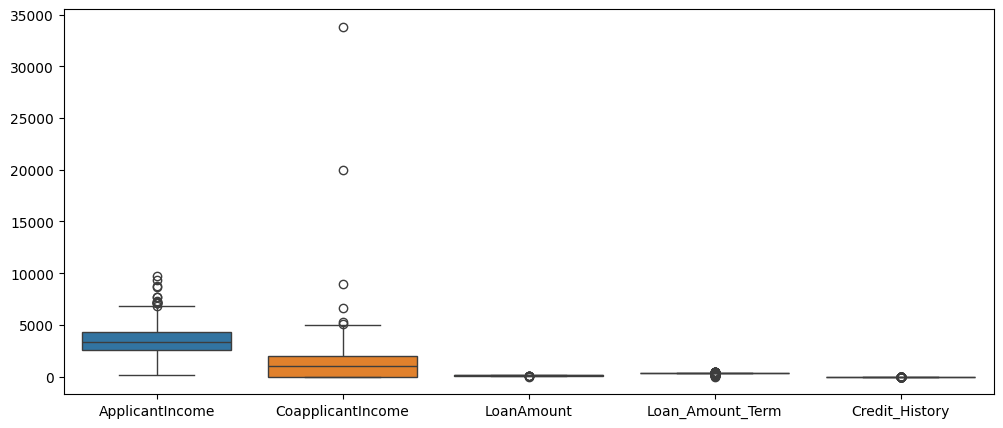

In [ ]:
a=df.select_dtypes(exclude="object")
plt.figure(figsize=(12,5))
sns.boxplot(data=a)
plt.show()

In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,No
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Yes
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Yes
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Yes
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,LP002953,Male,Yes,3+,Graduate,No,5703,0.0,128.0,360.0,1.0,Urban,Yes
377,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Yes
378,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Yes
379,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Yes


In [ ]:
#step5 feature engineering
df["Loan_Status"]=df["Loan_Status"].replace({"Y":"yes","N":"No"})
df.head()
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
376,LP002953,Male,Yes,3+,Graduate,No,5703,0.0,128.0,360.0,1.0,Urban,Yes
377,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Yes
378,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Yes
379,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Yes
380,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,No


In [ ]:
df["Loan_Status"].value_counts()

,count
Loan_Status,
Yes,271
No,110


In [ ]:
df.groupby("Loan_Status")["LoanAmount"].mean().reset_index()


,Loan_Status,LoanAmount
0,No,103.154545
1,Yes,105.730627


In [ ]:
df.groupby("Loan_Status")["LoanAmount"].min().reset_index()


,Loan_Status,LoanAmount
0,No,9.0
1,Yes,17.0


In [ ]:
df.groupby("Loan_Status")["LoanAmount"].max().reset_index()


,Loan_Status,LoanAmount
0,No,150.0
1,Yes,150.0


In [ ]:

df.groupby("Loan_Status")["LoanAmount"].median().reset_index()


,Loan_Status,LoanAmount
0,No,106.0
1,Yes,111.0


In [ ]:
df.groupby("Loan_Status")["LoanAmount"].count().reset_index()


,Loan_Status,LoanAmount
0,No,110
1,Yes,271


In [ ]:
df.groupby("Loan_Status")["ApplicantIncome"].min().reset_index()


,Loan_Status,ApplicantIncome
0,No,150
1,Yes,210


In [ ]:
df.groupby("Loan_Status")["CoapplicantIncome"].mean().reset_index()


,Loan_Status,CoapplicantIncome
0,No,1244.190909
1,Yes,1290.704502


In [ ]:
df.groupby('Property_Area')['LoanAmount'].mean().reset_index()


,Property_Area,LoanAmount
0,Rural,110.264151
1,Semiurban,106.805369
2,Urban,98.396825


In [ ]:
df.groupby('Loan_Status')['Property_Area'].value_counts().reset_index()


,Loan_Status,Property_Area,count
0,No,Rural,41
1,No,Urban,39
2,No,Semiurban,30
3,Yes,Semiurban,119
4,Yes,Urban,87
5,Yes,Rural,65


In [ ]:
df.groupby("Gender")["Loan_Status"].value_counts()

Gender  Loan_Status
Female  Yes             59
        No              26
Male    Yes            212
        No              84
Name: count, dtype: int64

In [ ]:
df.groupby("Education")["Loan_Status"].value_counts()

Education     Loan_Status
Graduate      Yes            202
              No              76
Not Graduate  Yes             69
              No              34
Name: count, dtype: int64

In [ ]:
df.groupby("Married")["Loan_Status"].value_counts()

Married  Loan_Status
No       Yes            101
         No              52
Yes      Yes            170
         No              58
Name: count, dtype: int64

In [ ]:
df.groupby("Dependents")["Loan_Status"].value_counts()

Dependents  Loan_Status
0           Yes            172
            No              70
1           Yes             35
            No              17
2           Yes             44
            No              15
3+          Yes             20
            No               8
Name: count, dtype: int64

In [ ]:
df.groupby("Self_Employed")["Loan_Status"].value_counts()

Self_Employed  Loan_Status
No             Yes            247
               No              99
Yes            Yes             24
               No              11
Name: count, dtype: int64

In [ ]:
df.groupby("Credit_History")["Loan_Status"].value_counts()

Credit_History  Loan_Status
0.000000        No              54
                Yes              3
0.837607        Yes             26
                No               4
1.000000        Yes            242
                No              52
Name: count, dtype: int64

In [ ]:
df.groupby("Property_Area")["Loan_Status"].value_counts()

Property_Area  Loan_Status
Rural          Yes             65
               No              41
Semiurban      Yes            119
               No              30
Urban          Yes             87
               No              39
Name: count, dtype: int64

In [ ]:
df["ApplicantIncome"].mean()

np.float64(3579.845144356955)

In [ ]:
df["LoanAmount"].mean()

np.float64(104.98687664041995)

In [ ]:
df["LoanAmount"].min()

9.0

In [ ]:
df["LoanAmount"].max()

150.0

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,No
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Yes
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Yes
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Yes
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Yes


In [ ]:
df["ApplicantIncome"].mean()

np.float64(3579.845144356955)

In [ ]:
a=df.query("Gender=='Male'")["ApplicantIncome"].mean()
print("Average income of male applicants:",a)
b=df.query("Gender=='Female'")["ApplicantIncome"].mean()
print("Average income of female applicants:",b)


Average income of male applicants: 3606.300675675676
Average income of female applicants: 3487.7176470588233


In [ ]:
a=df.query("Gender=='Female' and Loan_Status=='Yes' and LoanAmount>104.98").shape[0]
print("Number of approved Female applicants:",a)
b=df.query("Gender=='Female' and Loan_Status=='Yes' and LoanAmount<104.98").shape[0]
print("Number of rejected Female applicants:",b)

Number of approved Female applicants: 34
Number of rejected Female applicants: 25


In [ ]:
a=df.query("Loan_Status=='Yes' and LoanAmount>8 and LoanAmount<57").shape[0]
print("Number of approved applicants within LoanAmount 9-56:",a)
b=df.query("Loan_Status=='No' and LoanAmount>8 and LoanAmount<57").shape[0]
print("Number of rejected applicants within LoanAmount 9-56:",b)




Number of approved applicants within LoanAmount 9-56: 24
Number of rejected applicants within LoanAmount 9-56: 5


In [ ]:
a=df.query("Loan_Status=='Yes' and LoanAmount>56 and LoanAmount<104").shape[0]
print("Number of approved applicants within LoanAmount 57-103:",a)
b=df.query("Loan_Status=='No' and LoanAmount>56 and LoanAmount<104").shape[0]
print("Number of rejected applicants within LoanAmount 57-103:",b)


Number of approved applicants within LoanAmount 57-103: 82
Number of rejected applicants within LoanAmount 57-103: 44


In [ ]:
a=df.query("Loan_Status=='Yes' and LoanAmount>103 and LoanAmount<151").shape[0]
print("Number of approved applicants within LoanAmount 104-150:",a)
b=df.query("Loan_Status=='No' and LoanAmount>103 and LoanAmount<151").shape[0]
print("Number of rejected applicants within LoanAmount 104-150:",b)


Number of approved applicants within LoanAmount 104-150: 165
Number of rejected applicants within LoanAmount 104-150: 61


In [ ]:
a=df.query("Gender=='Male' and Loan_Status=='Yes' and LoanAmount>8 and LoanAmount<57").shape[0]
print("Number of approved applicants within LoanAmount 9-56 :",a)
b=df.query("Gender=='Male' and Loan_Status=='No' and LoanAmount>8 and LoanAmount<57").shape[0]
print("Number of rejected applicants within LoanAmount 9-56 :",b)


Number of approved applicants within LoanAmount 9-56 : 18
Number of rejected applicants within LoanAmount 9-56 : 3


In [ ]:
a=df.query("Gender=='Male' and Loan_Status=='Yes' and LoanAmount>56 and LoanAmount<104").shape[0]
print("Number of approved applicants within LoanAmount 57-103:",a)
b=df.query("Gender=='Male' and Loan_Status=='No' and LoanAmount>56 and LoanAmount<104").shape[0]
print("Number of rejecetd applicants within LoanAmount 57-103:",b)


Number of approved applicants within LoanAmount 57-103: 63
Number of rejecetd applicants within LoanAmount 57-103: 32


In [ ]:
a=df.query("Gender=='Male' and Loan_Status=='Yes' and LoanAmount>103 and LoanAmount<151").shape[0]
print("Number of approved applicants within LoanAmount 104-150:",a)
b=df.query("Gender=='Male' and Loan_Status=='No' and LoanAmount>103 and LoanAmount<151").shape[0]
print("Number of rejected applicants within LoanAmount 104-150:",b)


Number of approved applicants within LoanAmount 104-150: 131
Number of rejected applicants within LoanAmount 104-150: 49


In [ ]:
a=df.query("Gender=='Female' and Loan_Status=='Yes' and LoanAmount>8 and LoanAmount<57").shape[0]
print("Number of approved applicants within LoanAmount 9-56:",a)
b=df.query("Gender=='Female' and Loan_Status=='No' and LoanAmount>LoanAmount>8 and LoanAmount<57").shape[0]
print("Number of rejected applicants within LoanAmount 9-56:",b)


Number of approved applicants within LoanAmount 9-56: 6
Number of rejected applicants within LoanAmount 9-56: 0


In [ ]:
a=df.query("Gender=='Female' and Loan_Status=='Yes' and LoanAmount>56 and LoanAmount<104").shape[0]
print("Number of approved applicants within LoanAmount 57-103:",a)
b=df.query("Gender=='Female' and Loan_Status=='No' and LoanAmount>56 and LoanAmount<104").shape[0]
print("Number of rejected applicants within LoanAmount 57-103:",b)


Number of approved applicants within LoanAmount 57-103: 19
Number of rejected applicants within LoanAmount 57-103: 12


In [ ]:
a=df.query("Gender=='Female' and Loan_Status=='Yes' and LoanAmount>103 and LoanAmount<151").shape[0]
print("Number of approved applicants within LoanAmount 104-150:",a)
b=df.query("Gender=='Female' and Loan_Status=='No' and LoanAmount>103 and LoanAmount<151").shape[0]
print("Number of rejected applicants within LoanAmount 104-150:",b)


Number of approved applicants within LoanAmount 104-150: 34
Number of rejected applicants within LoanAmount 104-150: 12


In [ ]:

df["Gender"].value_counts()

,count
Gender,
Male,296
Female,85


In [ ]:

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,No
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Yes
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Yes
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Yes
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Yes


In [ ]:
a=df.query("Gender=='Male' and Loan_Status=='Yes' and LoanAmount>104.98").shape[0]
print("Number of approved Male applicants:",a)
b=df.query("Gender=='Male' and Loan_Status=='Yes' and LoanAmount>104.98").shape[0]
print("Number of rejected Male applicants:",b)

Number of approved Male applicants: 127
Number of rejected Male applicants: 127


In [ ]:
b=df.query("Gender=='Female' and Loan_Status=='Yes' and LoanAmount<104.98").shape[0]
print("Number of rejected Female applicants:",b)
b=df.query("Gender=='Male' and Loan_Status=='Yes' and LoanAmount>104.98").shape[0]
print("Number of rejected Male applicants:",b)

Number of rejected Female applicants: 25
Number of rejected Male applicants: 127


In [ ]:
df.groupby("Gender")["Loan_Status"].value_counts()

Gender  Loan_Status
0       1               59
        0               26
1       1              212
        0               84
Name: count, dtype: int64

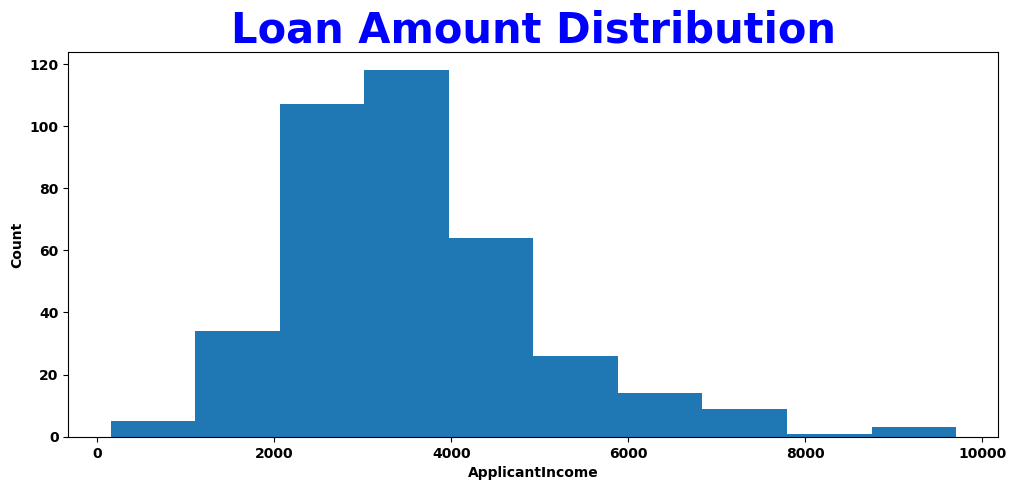

In [ ]:

#Step7 EDA
plt.figure(figsize=(12,5))
plt.title("Loan Amount Distribution",fontweight="bold",fontsize="30",color="blue")
plt.hist(df["ApplicantIncome"],bins=10)
plt.xlabel("ApplicantIncome",fontweight="bold")
plt.ylabel("Count",fontweight="bold")
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.show()


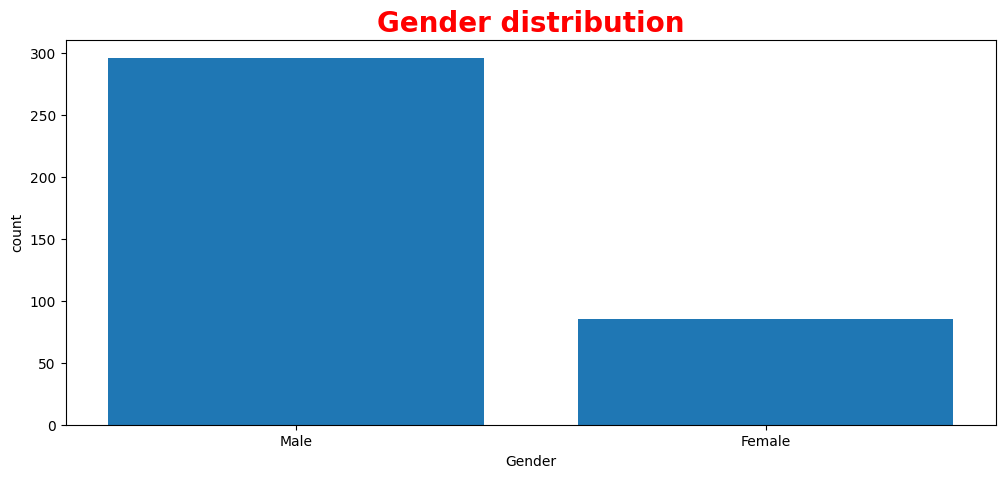

In [ ]:
a=df["Gender"].value_counts()
plt.figure(figsize=(12,5))
plt.title("Gender distribution",fontweight="bold",fontsize=20,color="red")
plt.bar(a.index,a.values)
plt.xlabel('Gender')
plt.ylabel("count")
plt.show()

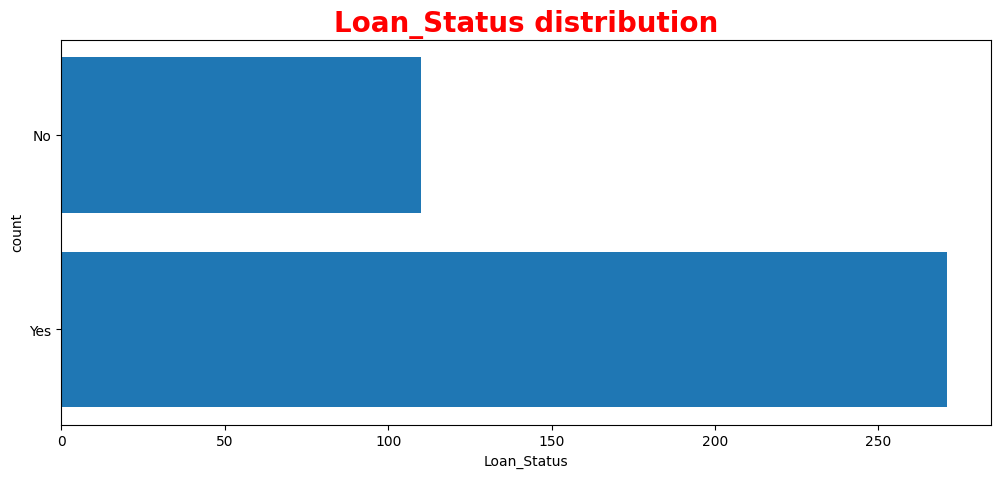

In [ ]:

a=df["Loan_Status"].value_counts()
plt.figure(figsize=(12,5))
plt.title("Loan_Status distribution",fontweight="bold",fontsize=20,color="red")
plt.barh(a.index,a.values)
plt.xlabel('Loan_Status')
plt.ylabel("count")
plt.show()

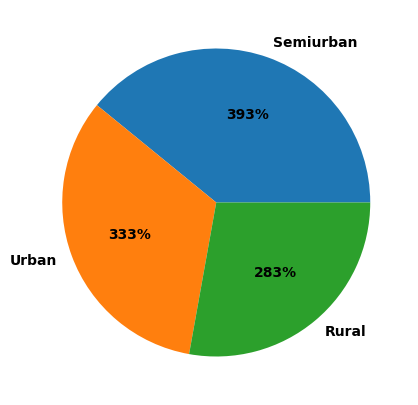

In [ ]:
a=df["Property_Area"].value_counts()
plt.figure(figsize=(12,5))
plt.pie(a.values,labels=a.index,autopct='%1.f3%%',textprops={'fontweight':'bold'})
plt.show()

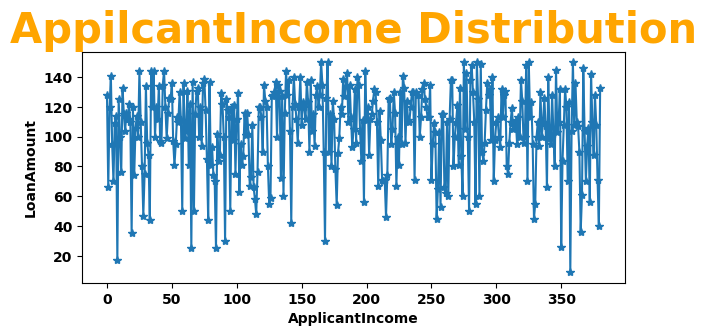

In [ ]:
plt.figure(figsize=(7,3))
plt.plot(df['LoanAmount'],marker='*')
plt.title("AppilcantIncome Distribution",fontweight="bold",fontsize="30",color="orange")
plt.xlabel("ApplicantIncome",fontweight="bold")
plt.ylabel("LoanAmount",fontweight="bold")
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.show()


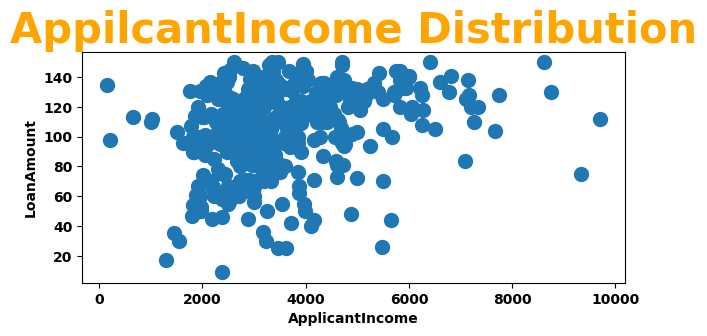

In [ ]:
plt.figure(figsize=(7,3))
plt.scatter(df['ApplicantIncome'],df['LoanAmount'],s=100)
plt.title("AppilcantIncome Distribution",fontweight="bold",fontsize="30",color="orange")
plt.xlabel("ApplicantIncome",fontweight="bold")
plt.ylabel("LoanAmount",fontweight="bold")
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.show()


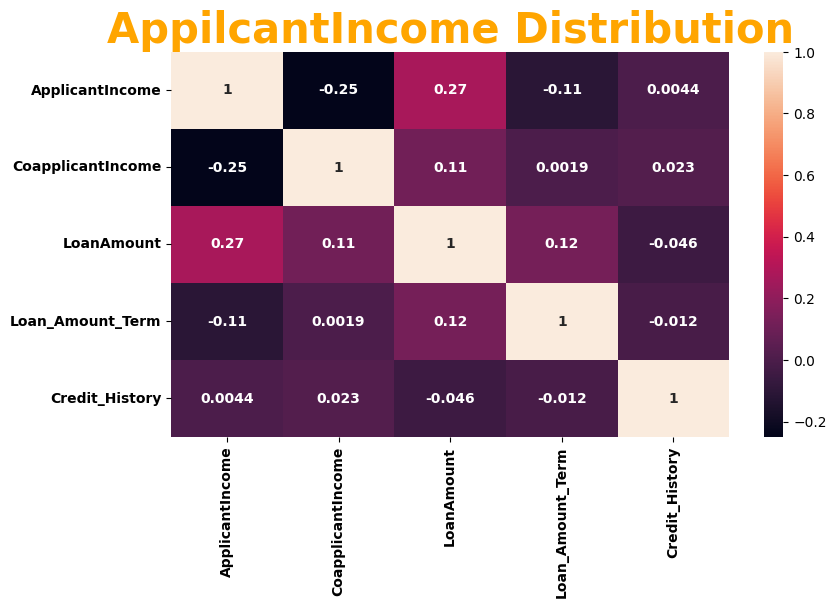

In [ ]:
a=df.select_dtypes(exclude='object')
plt.figure(figsize=(9,5))
plt.title("AppilcantIncome Distribution",fontweight="bold",fontsize="30",color="orange")
b=a.corr()
sns.heatmap(b,annot=True,annot_kws={'fontweight':'bold'})
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             381 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         381 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      381 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   381 non-null    float64
 10  Credit_History     381 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             381 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         381 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      381 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   381 non-null    float64
 10  Credit_History     381 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [ ]:
cat_cols = df.select_dtypes(include = 'object')
print(cat_cols)

      Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001003    Male     Yes          1      Graduate            No   
1    LP001005    Male     Yes          0      Graduate           Yes   
2    LP001006    Male     Yes          0  Not Graduate            No   
3    LP001008    Male      No          0      Graduate            No   
4    LP001013    Male     Yes          0  Not Graduate            No   
..        ...     ...     ...        ...           ...           ...   
376  LP002953    Male     Yes         3+      Graduate            No   
377  LP002974    Male     Yes          0      Graduate            No   
378  LP002978  Female      No          0      Graduate            No   
379  LP002979    Male     Yes         3+      Graduate            No   
380  LP002990  Female      No          0      Graduate           Yes   

    Property_Area Loan_Status  
0           Rural          No  
1           Urban         Yes  
2           Urban         Yes  
3      

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             381 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         381 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      381 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   381 non-null    float64
 10  Credit_History     381 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
Yes,271
No,110


In [ ]:
df['Property_Area'].value_counts()

,count
Property_Area,
Semiurban,149
Urban,126
Rural,106


In [ ]:
df['Credit_History'].value_counts()

,count
Credit_History,
1.000000,294
0.000000,57
0.837607,30


In [ ]:
cat_cols = df.select_dtypes(include = 'object')

for i in cat_cols:
  le = LabelEncoder()
  df[i] = le.fit_transform(df[i])
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
1,1,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
2,2,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
3,3,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
4,4,1,1,0,1,0,2333,1516.0,95.0,360.0,1.0,2,1


In [ ]:
#Step 9 Split x and y
X=df.drop(["Loan_Status", "Loan_ID"],axis=1)
y=df["Loan_Status"]

In [ ]:
y

,Loan_Status
0,0
1,1
2,1
3,1
4,1
...,...
376,1
377,1
378,1
379,1


In [ ]:
#Step 10 Train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42, stratify = y)

In [ ]:
#Step 11 Scaling
Scalar=StandardScaler()
X_train=Scalar.fit_transform(X_train)
X_test=Scalar.transform(X_test)
X_train

array([[ 0.5061604 ,  0.82435309,  1.3901677 , ...,  0.3085278 ,
        -2.34850724, -0.07110108],
       [ 0.5061604 ,  0.82435309, -0.67638966, ...,  0.3085278 ,
         0.46656726, -0.07110108],
       [ 0.5061604 ,  0.82435309,  1.3901677 , ...,  0.3085278 ,
         0.46656726,  1.20035359],
       ...,
       [ 0.5061604 , -1.21307243, -0.67638966, ..., -2.43741353,
         0.46656726,  1.20035359],
       [-1.97565832, -1.21307243, -0.67638966, ...,  0.01661692,
         0.46656726,  1.20035359],
       [ 0.5061604 , -1.21307243, -0.67638966, ..., -0.60678598,
         0.46656726, -1.34255576]])

In [ ]:
#Step 12 Train classificaton model

model=LogisticRegression()

In [ ]:
#Step 13 Fit Model

model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
model_pred=model.predict(X_test)

In [ ]:
print(f"accuracy score: {accuracy_score(y_test,model_pred):.2f}")

accuracy score: 0.86


In [ ]:
#Step 16
print("Confusion matrix\n",confusion_matrix(y_test,model_pred))

Confusion matrix
 [[11 11]
 [ 0 55]]


In [ ]:
print("Classification report\n",classification_report(y_test,model_pred))

Classification report
               precision    recall  f1-score   support

           0       1.00      0.50      0.67        22
           1       0.83      1.00      0.91        55

    accuracy                           0.86        77
   macro avg       0.92      0.75      0.79        77
weighted avg       0.88      0.86      0.84        77



In [ ]:
model2=DecisionTreeClassifier()


In [ ]:
model2.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred2=model2.predict(X_test)

In [ ]:
print(f"accuracy score: {accuracy_score(y_test,y_pred2):.2f}")

accuracy score: 0.83


In [ ]:
print("Confusion matrix\n",confusion_matrix(y_test,y_pred2))

Confusion matrix
 [[14  8]
 [ 5 50]]


In [ ]:
print("Classification report\n",classification_report(y_test,y_pred2))

Classification report
               precision    recall  f1-score   support

           0       0.74      0.64      0.68        22
           1       0.86      0.91      0.88        55

    accuracy                           0.83        77
   macro avg       0.80      0.77      0.78        77
weighted avg       0.83      0.83      0.83        77



In [ ]:
model3=RandomForestClassifier()

In [ ]:
model3.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred3=model3.predict(X_test)


In [ ]:
print(f"accuracy score:{accuracy_score(y_test,y_pred3):.2f}")

accuracy score:0.84


In [ ]:
print("Confusion matrix\n",confusion_matrix(y_test,y_pred3))

Confusion matrix
 [[12 10]
 [ 2 53]]


In [ ]:
print("Classification report\n",classification_report(y_test,y_pred3))

Classification report
               precision    recall  f1-score   support

           0       0.86      0.55      0.67        22
           1       0.84      0.96      0.90        55

    accuracy                           0.84        77
   macro avg       0.85      0.75      0.78        77
weighted avg       0.85      0.84      0.83        77

